# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms

from os import path

from torch.utils.data import TensorDataset

from utils.plot import plot_digit_histograms

from scipy.ndimage import center_of_mass, shift

from sklearn.model_selection import StratifiedShuffleSplit

In [2]:
# Setting torch seed
random_seed = 42
torch.manual_seed(random_seed)

# Import fine tunning data

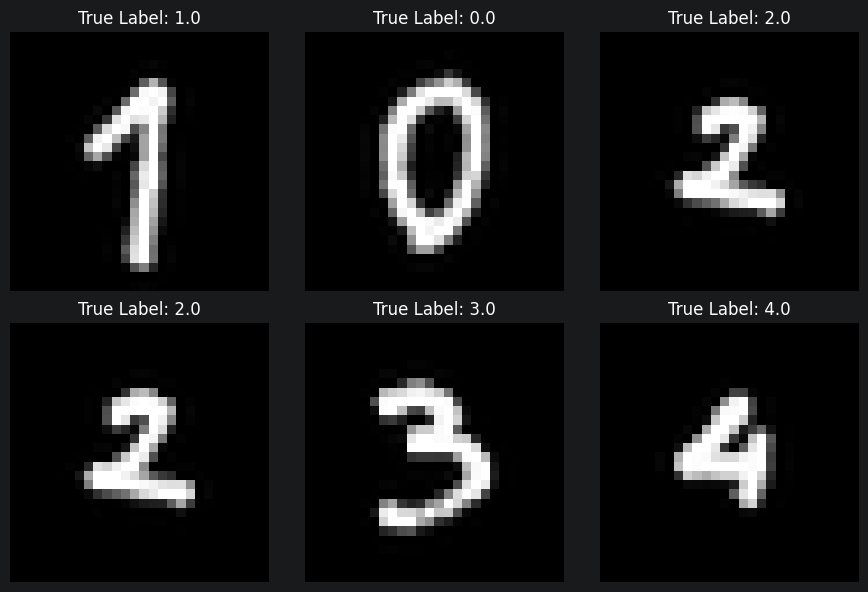

In [3]:
PATH = "fine-tuning-data-collector/fine_tune_data.csv"

line_data = np.genfromtxt(PATH, delimiter=',')

line_data = line_data[1:]

true_labels = np.array([d[0] for d in line_data], dtype=np.float32)
# Reshape, normalize in one line
data = np.array([(np.array(d[1:], dtype=np.float32) / 255.0).reshape((28, 28)) for d in line_data])

# Center image
centered_images = []
for img in data:
    if img.sum() < 1e-5:
        centered_images.append(img)
        continue

    c_y, c_x = center_of_mass(img)

    shift_x = 13.5 - c_x
    shift_y = 13.5 - c_y

    centered_image = shift(img, shift=(shift_y, shift_x), cval=0.0)
    centered_images.append(centered_image)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.imshow(centered_images[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"True Label: {true_labels[i]}")
    ax.axis('off')

plt.tight_layout()
# plt.savefig("six_images_subplots.png")

# Dara Preparation

## Splitting and shuffling data

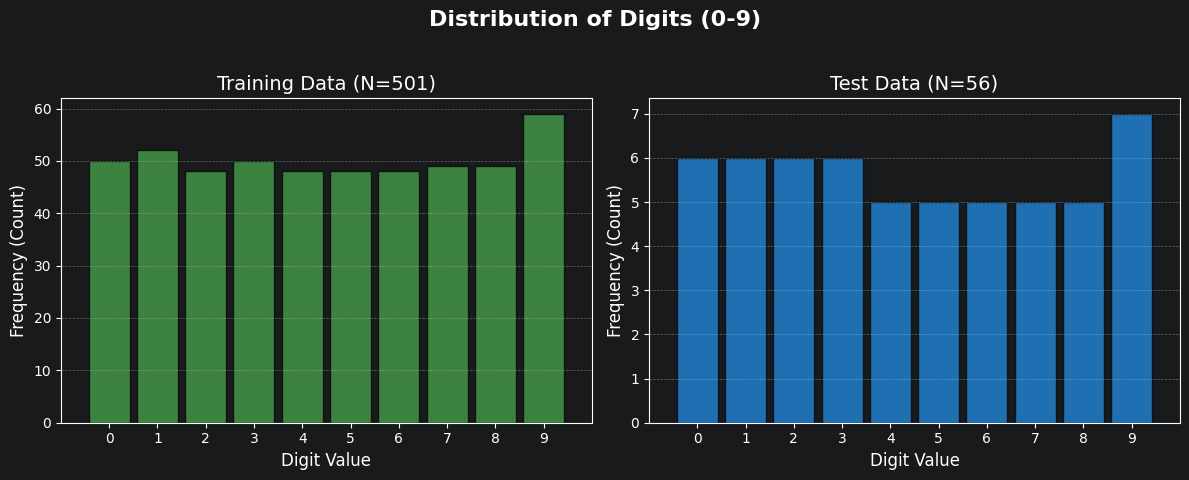

[4. 8. 1. 7. 1. 9. 2. 4. 2. 1. 9. 8. 1. 4. 5. 9. 0. 3. 0. 3. 1. 8. 3. 7.
 9. 6. 0. 9. 5. 0. 2. 7. 6. 2. 3. 5. 5. 8. 6. 1. 7. 2. 8. 7. 4. 0. 4. 9.
 3. 0. 9. 3. 6. 5. 2. 6.]


In [4]:
np.random.seed(42)

# Use StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=random_seed)

N = len(data)

true_labels = np.array(true_labels)

train_idx, test_idx = next(sss.split(data, true_labels))

x_train, y_train = data[train_idx], true_labels[train_idx]
x_test, y_test = data[test_idx], true_labels[test_idx]

plot_digit_histograms(y_train, y_test)

print(y_test)

## Prepare data for torch

In [5]:
# Move Data to tensors
add_channel = lambda x: x.unsqueeze(1)

x_train_tensor, y_train_tensor = add_channel(torch.from_numpy(x_train)), torch.from_numpy(y_train).long()
x_test_tensor, y_test_tensor = add_channel(torch.from_numpy(x_test)), torch.from_numpy(y_test).long()

# Prepare Dataset
train_set = TensorDataset(x_train_tensor, y_train_tensor)
test_set = TensorDataset(x_test_tensor, y_test_tensor)

# Data loaders
train_batch_size = 16
test_batch_size = len(test_set)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=train_batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=test_batch_size, shuffle=True)

examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

example_data[0].shape

torch.Size([1, 28, 28])

## Define Transform (data augmentation)

In [6]:
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomRotation(degrees=5),
    torchvision.transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.10)),
    # torchvision.transforms.ElasticTransform(alpha=10.0, sigma=5.0) # temporary remove ElasticTransform
])

# Loading Model and reasuming training

Epoch 1 | Train loss 0.6906 | Validate loss 0.5278
Epoch 2 | Train loss 0.6069 | Validate loss 0.4799
Epoch 3 | Train loss 0.5278 | Validate loss 0.3685
Epoch 4 | Train loss 0.4877 | Validate loss 0.3348
Epoch 5 | Train loss 0.4662 | Validate loss 0.3523
Epoch 6 | Train loss 0.4106 | Validate loss 0.2909
Epoch 7 | Train loss 0.4372 | Validate loss 0.2550
Epoch 8 | Train loss 0.3358 | Validate loss 0.2444
Epoch 9 | Train loss 0.3629 | Validate loss 0.2449
Epoch 10 | Train loss 0.2862 | Validate loss 0.2469
Epoch 11 | Train loss 0.2869 | Validate loss 0.2276
Epoch 12 | Train loss 0.3368 | Validate loss 0.2061
Epoch 13 | Train loss 0.2986 | Validate loss 0.2044
Epoch 14 | Train loss 0.2991 | Validate loss 0.1913
Epoch 15 | Train loss 0.2734 | Validate loss 0.1986
Epoch 16 | Train loss 0.2984 | Validate loss 0.1884
Epoch 17 | Train loss 0.2633 | Validate loss 0.1741
Epoch 18 | Train loss 0.2141 | Validate loss 0.1721
Epoch 19 | Train loss 0.2465 | Validate loss 0.1843
Epoch 20 | Train loss

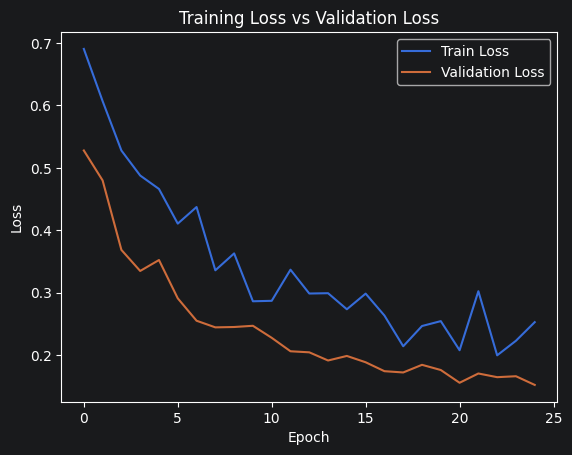

In [7]:
from models_arch.Recognizer import RecognizerOneConv as MyModel

# Hyperparameters
n_epochs = 25
learning_rate = 0.1e-3

# Use GPU acceleration if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
PARAMS_PATH = path.join("trained_models", "RecognizerOneConv.pth")
model = MyModel().to(device)
model.load_state_dict(torch.load(PARAMS_PATH, map_location=device))

# Freeze convolutional layers
for layer in model:
    if isinstance(layer, nn.Conv2d):
        for param in layer.parameters():
            param.requires_grad = False

# Update only the unfrozen layers
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

criterion = nn.CrossEntropyLoss() # Change loss function from NLLLoss because model outputs raw logits

train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = []
    for batch_idx, (data, target) in enumerate(train_loader):
        # Apply data augmentation
        data = train_transform(data)

        # Transfer data to GPU
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)

        loss = criterion(output, target)
        epoch_loss.append(loss.item())

        loss.backward()
        optimizer.step()

    # Calculate average loss for the entire epoch
    avg_loss = sum(epoch_loss) / len(epoch_loss)
    train_losses.append(avg_loss)

    # Validate on the test set
    model.eval()
    epoch_val_loss = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            epoch_val_loss.append(loss.item())
    avg_val_loss = sum(epoch_val_loss) / len(epoch_val_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1} | Train loss {avg_loss:.4f} | Validate loss {avg_val_loss:.4f}")

# Training Loss vs Validation Loss (to prevent overfitting)
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Model Testing


In [8]:
# WE CANNOT USE DATA FROM TEST_LOADER BECAUSE OF DATA LEAKAGE RIGHT NOW, IF WE WANT TO TEST THE MODEL'S ACCURACY, WE NEED TO CREATE ADDITIONAL TEST AND VALIDATION SET (RIGHT NOW, DUE TO INSUFFICIENT DATA IN THE CSV FILE FOR FINE-TUNING, IT IS IMPOSSIBLE
# DECOMMENT JUST FOR

model.eval()

# Disable gradient calculation
with torch.no_grad():
    correct = 0
    for (data, target) in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        y_hat = output.data.max(1, keepdim=True)[1]
        correct += y_hat.eq(target.data.view_as(y_hat)).sum()

accuracy = correct / len(test_set)

print(f"{accuracy=}")

accuracy=tensor(0.9643, device='cuda:0')


# Saving a model


In [9]:
torch.save(model.state_dict(), "trained_models/model_fine_tuned.pth")